In [51]:
# =========================================================
# ASD PREDICTION NOTEBOOK - FULL CLEAN VERSION
# Includes:
# 1. EDA
# 2. Correlation heatmap of selected features
# 3. Preprocessing
# 4. Model training
# 5. Confusion matrices
# 6. Accuracy comparison bar graph
# 7. ROC-AUC curves
# 8. SHAP explainability
# =========================================================

# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Optional installs for explanation
!pip install shap -q

import shap


In [52]:
# -----------------------------
# 2. LOAD DATASET
# -----------------------------
# Change path only if needed
df = pd.read_csv("/kaggle/input/datasets/stealthtechnologies/predict-autism-spectrum-disorder-asd/Autism.csv")

print("Dataset Shape:", df.shape)
print("\nDataset Info:")
print(df.info())

print("\nFirst 5 rows:")
display(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Class Distribution:")
print(df["Class/ASD"].value_counts())
print(df["Class/ASD"].value_counts(normalize=True) * 100)

Dataset Shape: (704, 21)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   A1_Score         704 non-null    int64 
 1   A2_Score         704 non-null    int64 
 2   A3_Score         704 non-null    int64 
 3   A4_Score         704 non-null    int64 
 4   A5_Score         704 non-null    int64 
 5   A6_Score         704 non-null    int64 
 6   A7_Score         704 non-null    int64 
 7   A8_Score         704 non-null    int64 
 8   A9_Score         704 non-null    int64 
 9   A10_Score        704 non-null    int64 
 10  age              704 non-null    object
 11  gender           704 non-null    object
 12  ethnicity        704 non-null    object
 13  jundice          704 non-null    object
 14  austim           704 non-null    object
 15  contry_of_res    704 non-null    object
 16  used_app_before  704 non-null    object


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,'United States',no,6,'18 and more',Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5,'18 and more',Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8,'18 and more',Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,'United States',no,6,'18 and more',Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,?,no,no,Egypt,no,2,'18 and more',?,NO



Missing Values:
A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
age                0
gender             0
ethnicity          0
jundice            0
austim             0
contry_of_res      0
used_app_before    0
result             0
age_desc           0
relation           0
Class/ASD          0
dtype: int64

Target Class Distribution:
Class/ASD
NO     515
YES    189
Name: count, dtype: int64
Class/ASD
NO     73.153409
YES    26.846591
Name: proportion, dtype: float64


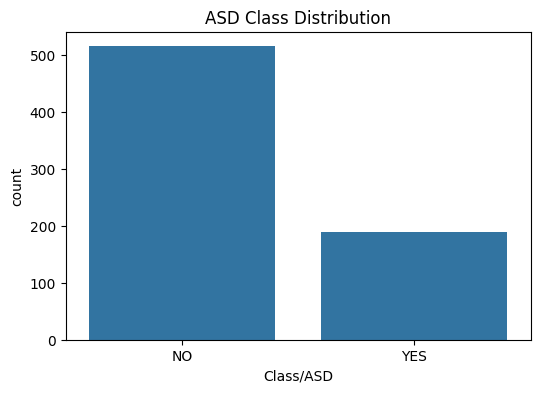

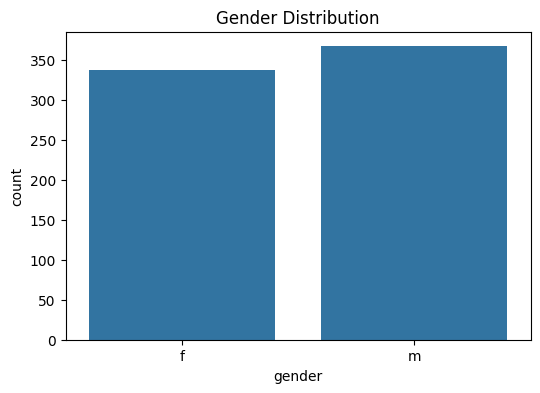

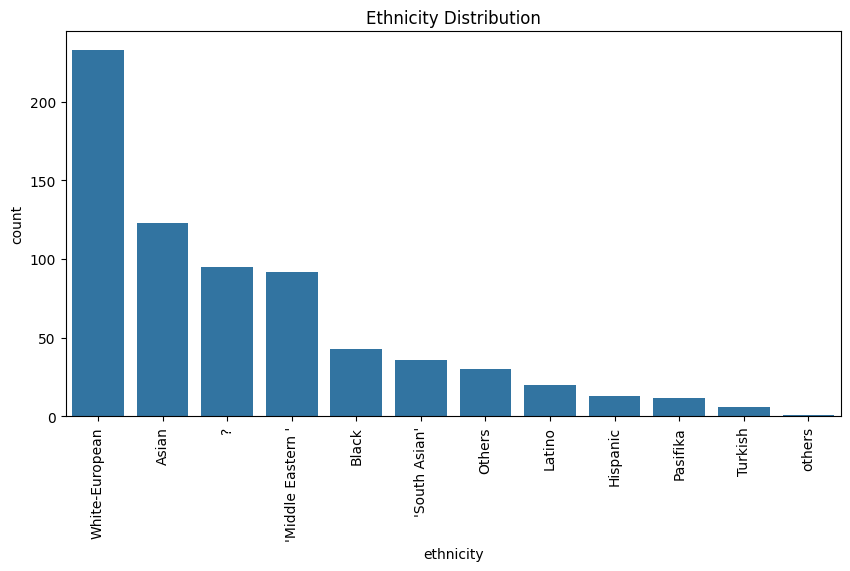

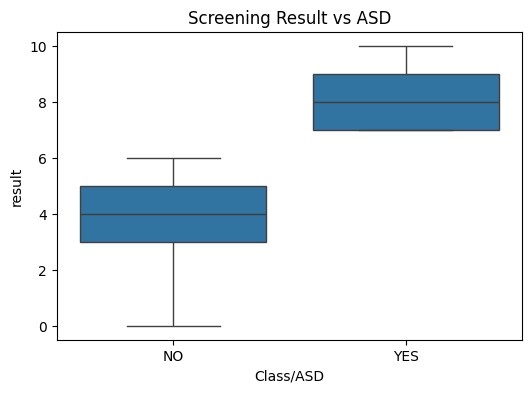

In [50]:
# -----------------------------
# 3. BASIC EDA
# -----------------------------
plt.figure(figsize=(6,4))
sns.countplot(x="Class/ASD", data=df)
plt.title("ASD Class Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="gender", data=df)
plt.title("Gender Distribution")
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(x="ethnicity", data=df, order=df["ethnicity"].value_counts().index)
plt.xticks(rotation=90)
plt.title("Ethnicity Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x="Class/ASD", y="result", data=df)
plt.title("Screening Result vs ASD")
plt.show()


In [53]:
# -----------------------------
# 4. PREPROCESSING
# -----------------------------
# Copy dataset
data_X = df.copy()

# Drop target and unnecessary columns
# IMPORTANT: 'result' removed to avoid target leakage
data_X = data_X.drop(["Class/ASD", "age_desc", "result"], axis=1)

# Target
y = df["Class/ASD"]

# Encode target
target_encoder = LabelEncoder()
Y = target_encoder.fit_transform(y)   # NO=0, YES=1

print("Target mapping:")
for i, cls in enumerate(target_encoder.classes_):
    print(f"{cls} -> {i}")

# Separate categorical columns
categorical_cols = data_X.select_dtypes(include="object").columns.tolist()
print("\nCategorical Columns:", categorical_cols)

# Label encode high-cardinality categorical columns
label_encode_cols = ["age", "ethnicity", "contry_of_res", "relation"]
label_encoder_dict = {}

for col in label_encode_cols:
    le = LabelEncoder()
    data_X[col] = le.fit_transform(data_X[col].astype(str))
    label_encoder_dict[col] = le

# One-hot encode binary / low-cardinality columns
one_hot_cols = ["gender", "jundice", "austim", "used_app_before"]

oneHotEncoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoded_array = oneHotEncoder.fit_transform(data_X[one_hot_cols])
encoded_cols = oneHotEncoder.get_feature_names_out(one_hot_cols)

encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=data_X.index)

# Drop original one-hot columns and join new columns
data_X = data_X.drop(columns=one_hot_cols)
data_X = pd.concat([data_X, encoded_df], axis=1)

# Ensure all data is numeric
data_X = data_X.apply(pd.to_numeric, errors="coerce")
data_X = data_X.fillna(0)

print("\nProcessed Feature Shape:", data_X.shape)
print("\nProcessed Features Preview:")
display(data_X.head())

print("\nDtypes:")
print(data_X.dtypes)

Target mapping:
NO -> 0
YES -> 1

Categorical Columns: ['age', 'gender', 'ethnicity', 'jundice', 'austim', 'contry_of_res', 'used_app_before', 'relation']

Processed Feature Shape: (704, 22)

Processed Features Preview:


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,contry_of_res,relation,gender_f,gender_m,jundice_no,jundice_yes,austim_no,austim_yes,used_app_before_no,used_app_before_yes
0,1,1,1,1,0,0,1,1,0,0,...,10,5,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,1,1,0,1,0,0,0,1,0,1,...,25,5,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
2,1,1,0,1,1,0,1,1,1,1,...,61,3,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
3,1,1,0,1,0,0,1,1,0,1,...,10,5,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
4,1,0,0,0,0,0,0,1,0,0,...,32,1,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0



Dtypes:
A1_Score                 int64
A2_Score                 int64
A3_Score                 int64
A4_Score                 int64
A5_Score                 int64
A6_Score                 int64
A7_Score                 int64
A8_Score                 int64
A9_Score                 int64
A10_Score                int64
age                      int64
ethnicity                int64
contry_of_res            int64
relation                 int64
gender_f               float64
gender_m               float64
jundice_no             float64
jundice_yes            float64
austim_no              float64
austim_yes             float64
used_app_before_no     float64
used_app_before_yes    float64
dtype: object


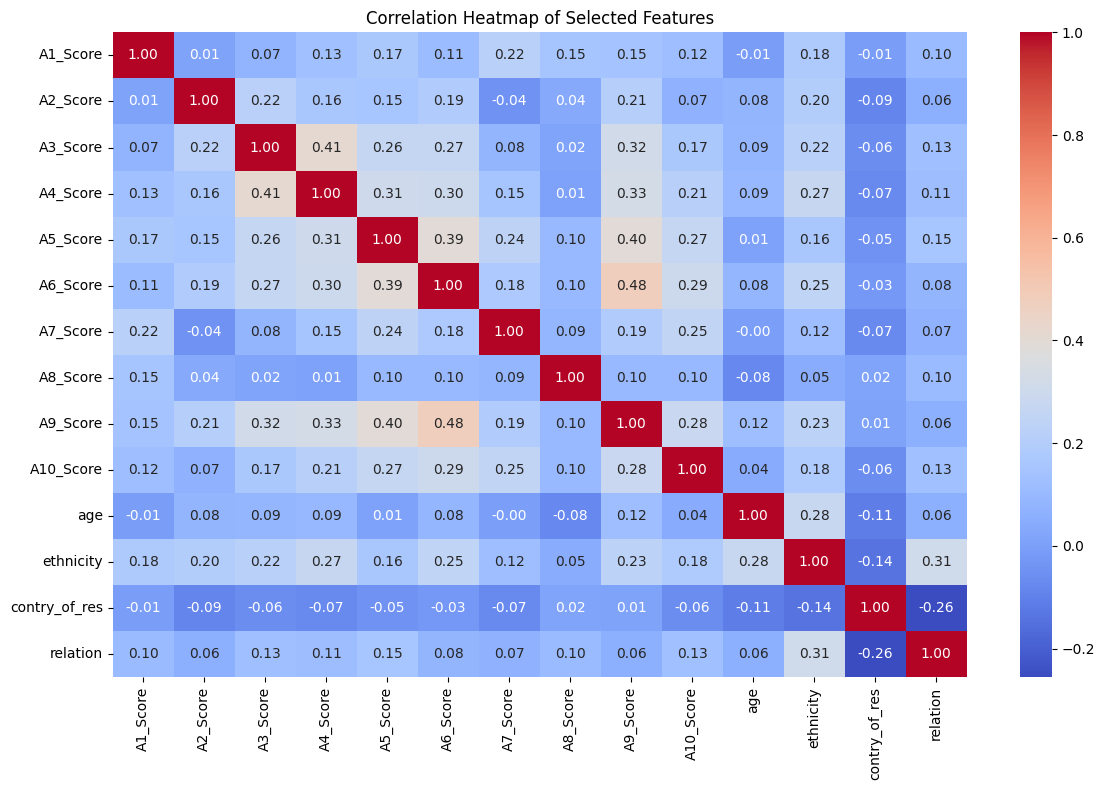

In [54]:
# -----------------------------
# 5. CORRELATION HEATMAP OF SELECTED FEATURES
# -----------------------------
# Select top related numeric features for a readable heatmap
selected_features = [
    "A1_Score", "A2_Score", "A3_Score", "A4_Score", "A5_Score",
    "A6_Score", "A7_Score", "A8_Score", "A9_Score", "A10_Score",
    "age", "ethnicity", "contry_of_res", "relation"
]

selected_features = [col for col in selected_features if col in data_X.columns]

plt.figure(figsize=(12,8))
sns.heatmap(data_X[selected_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Selected Features")
plt.tight_layout()
plt.show()

In [55]:
# -----------------------------
# 6. TRAIN-TEST SPLIT
# -----------------------------
X = data_X.copy()

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, shuffle=True, stratify=Y, random_state=1
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Y_train:", Y_train.shape)
print("Y_test :", Y_test.shape)


X_train: (563, 22)
X_test : (141, 22)
Y_train: (563,)
Y_test : (141,)


In [56]:
# -----------------------------
# 7. MODEL TRAINING
# -----------------------------
dt = DecisionTreeClassifier(max_depth=5, random_state=1)
rf = RandomForestClassifier(n_estimators=100, random_state=1)
svm = SVC(probability=True, random_state=1)
knn = KNeighborsClassifier(n_neighbors=5)

dt.fit(X_train, Y_train)
rf.fit(X_train, Y_train)
svm.fit(X_train, Y_train)
knn.fit(X_train, Y_train)

# Predictions
y_dt = dt.predict(X_test)
y_rf = rf.predict(X_test)
y_svm = svm.predict(X_test)
y_knn = knn.predict(X_test)

# Probabilities for ROC-AUC
y_dt_prob = dt.predict_proba(X_test)[:, 1]
y_rf_prob = rf.predict_proba(X_test)[:, 1]
y_svm_prob = svm.predict_proba(X_test)[:, 1]
y_knn_prob = knn.predict_proba(X_test)[:, 1]


In [57]:
# -----------------------------
# 8. CLASSIFICATION REPORTS
# -----------------------------
model_results = {
    "Decision Tree": y_dt,
    "Random Forest": y_rf,
    "SVM": y_svm,
    "KNN": y_knn
}

for model_name, y_pred in model_results.items():
    print("\n" + "="*60)
    print(f"{model_name} Classification Report")
    print("="*60)
    print(classification_report(Y_test, y_pred, target_names=target_encoder.classes_))



Decision Tree Classification Report
              precision    recall  f1-score   support

          NO       0.92      0.92      0.92       103
         YES       0.79      0.79      0.79        38

    accuracy                           0.89       141
   macro avg       0.86      0.86      0.86       141
weighted avg       0.89      0.89      0.89       141


Random Forest Classification Report
              precision    recall  f1-score   support

          NO       0.96      0.99      0.98       103
         YES       0.97      0.89      0.93        38

    accuracy                           0.96       141
   macro avg       0.97      0.94      0.95       141
weighted avg       0.96      0.96      0.96       141


SVM Classification Report
              precision    recall  f1-score   support

          NO       0.73      1.00      0.84       103
         YES       0.00      0.00      0.00        38

    accuracy                           0.73       141
   macro avg       0.37    

<Figure size 500x400 with 0 Axes>

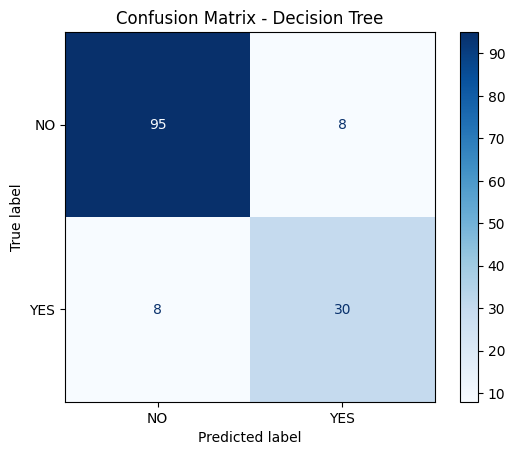

<Figure size 500x400 with 0 Axes>

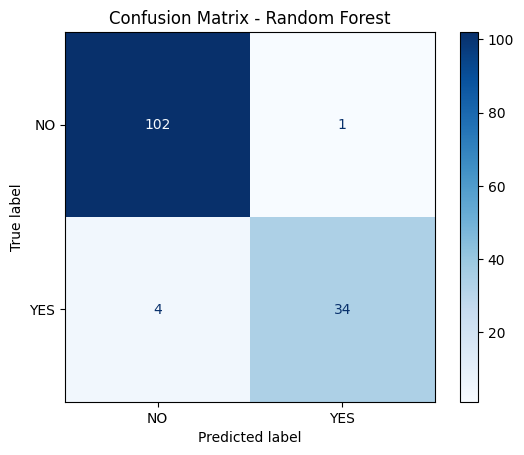

<Figure size 500x400 with 0 Axes>

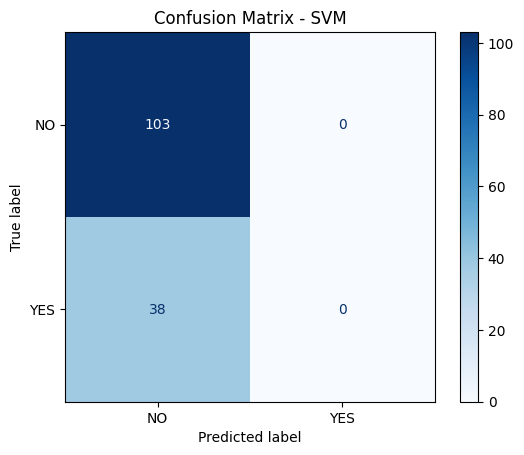

<Figure size 500x400 with 0 Axes>

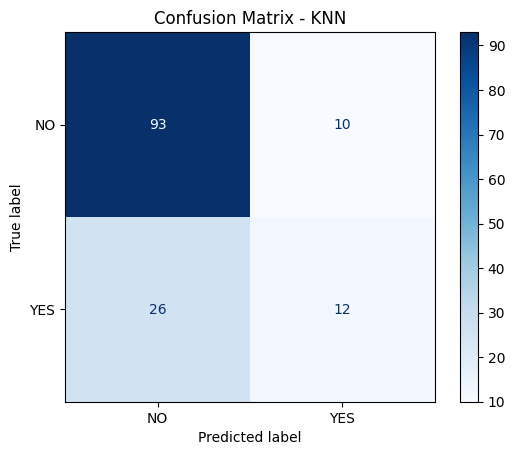

In [58]:
# -----------------------------
# 9. CONFUSION MATRICES
# -----------------------------
for model_name, y_pred in model_results.items():
    plt.figure(figsize=(5,4))
    cm = confusion_matrix(Y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_encoder.classes_)
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()


Model Comparison Table:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Decision Tree,0.886525,0.789474,0.789474,0.789474,0.880301
1,Random Forest,0.964539,0.971429,0.894737,0.931507,0.994124
2,SVM,0.730496,0.000000,0.000000,0.000000,0.917220
3,KNN,0.744681,0.545455,0.315789,0.400000,0.785514


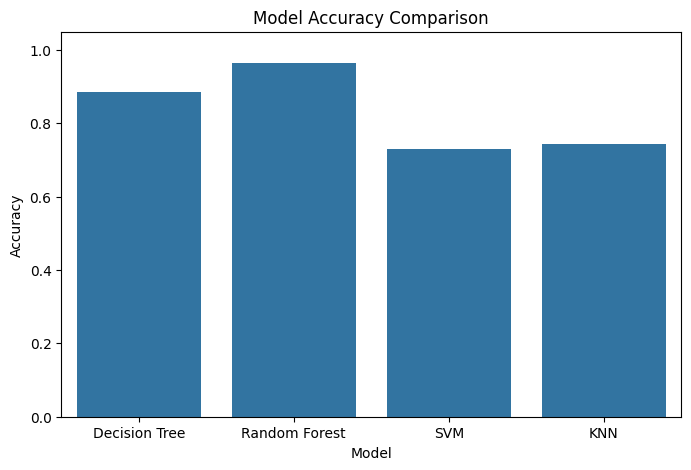

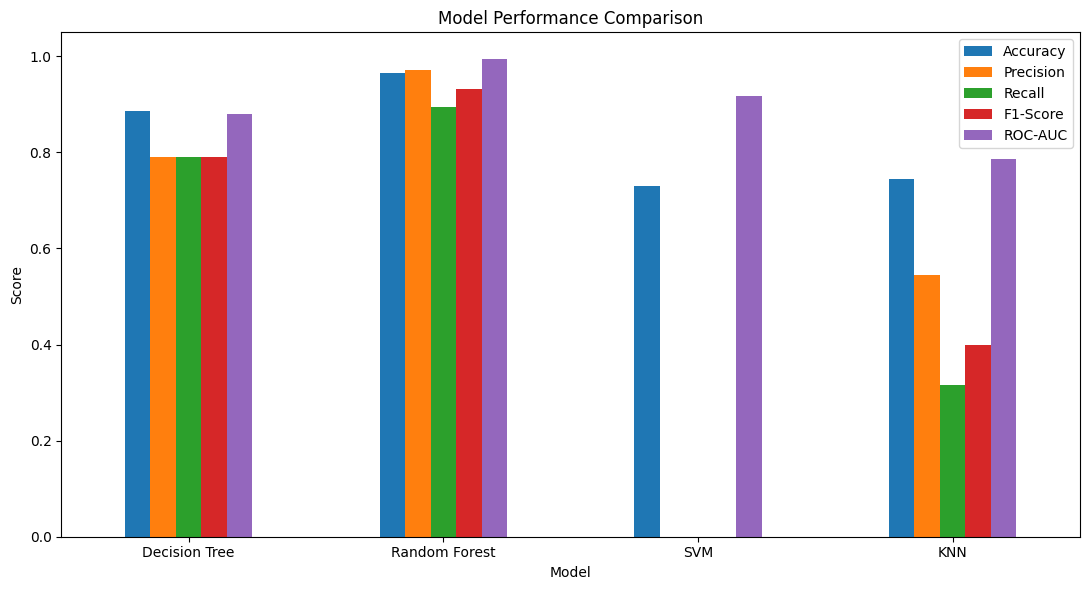

In [59]:
# -----------------------------
# 10. MODEL ACCURACY COMPARISON
# -----------------------------
comparison_df = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "SVM", "KNN"],
    "Accuracy": [
        accuracy_score(Y_test, y_dt),
        accuracy_score(Y_test, y_rf),
        accuracy_score(Y_test, y_svm),
        accuracy_score(Y_test, y_knn)
    ],
    "Precision": [
        precision_score(Y_test, y_dt),
        precision_score(Y_test, y_rf),
        precision_score(Y_test, y_svm),
        precision_score(Y_test, y_knn)
    ],
    "Recall": [
        recall_score(Y_test, y_dt),
        recall_score(Y_test, y_rf),
        recall_score(Y_test, y_svm),
        recall_score(Y_test, y_knn)
    ],
    "F1-Score": [
        f1_score(Y_test, y_dt),
        f1_score(Y_test, y_rf),
        f1_score(Y_test, y_svm),
        f1_score(Y_test, y_knn)
    ],
    "ROC-AUC": [
        roc_auc_score(Y_test, y_dt_prob),
        roc_auc_score(Y_test, y_rf_prob),
        roc_auc_score(Y_test, y_svm_prob),
        roc_auc_score(Y_test, y_knn_prob)
    ]
})

print("\nModel Comparison Table:")
display(comparison_df)

# Accuracy bar graph
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Accuracy", data=comparison_df)
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.show()

# Full metric comparison bar graph
comparison_plot_df = comparison_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]]
comparison_plot_df.plot(kind="bar", figsize=(11,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


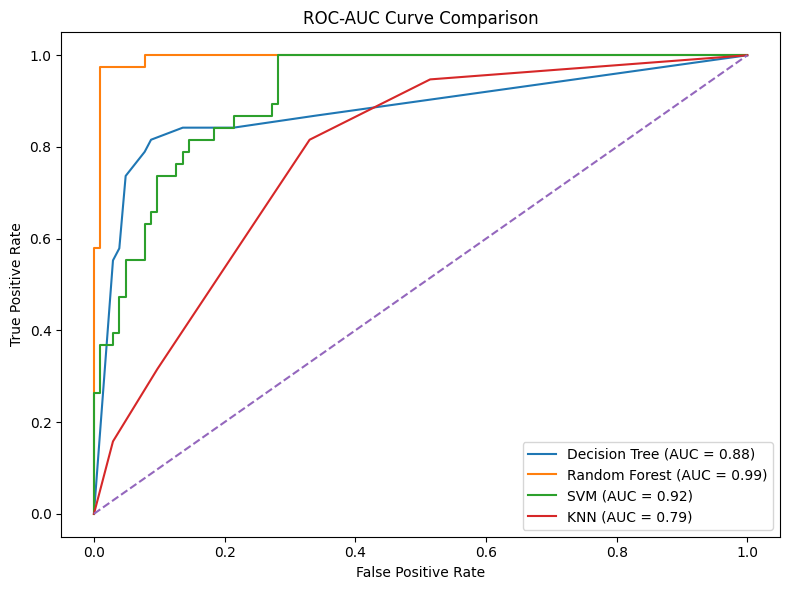

In [60]:
# -----------------------------
# 11. ROC-AUC CURVES
# -----------------------------
fpr_dt, tpr_dt, _ = roc_curve(Y_test, y_dt_prob)
fpr_rf, tpr_rf, _ = roc_curve(Y_test, y_rf_prob)
fpr_svm, tpr_svm, _ = roc_curve(Y_test, y_svm_prob)
fpr_knn, tpr_knn, _ = roc_curve(Y_test, y_knn_prob)

auc_dt = roc_auc_score(Y_test, y_dt_prob)
auc_rf = roc_auc_score(Y_test, y_rf_prob)
auc_svm = roc_auc_score(Y_test, y_svm_prob)
auc_knn = roc_auc_score(Y_test, y_knn_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.2f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {auc_knn:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()


Running SHAP on Random Forest...


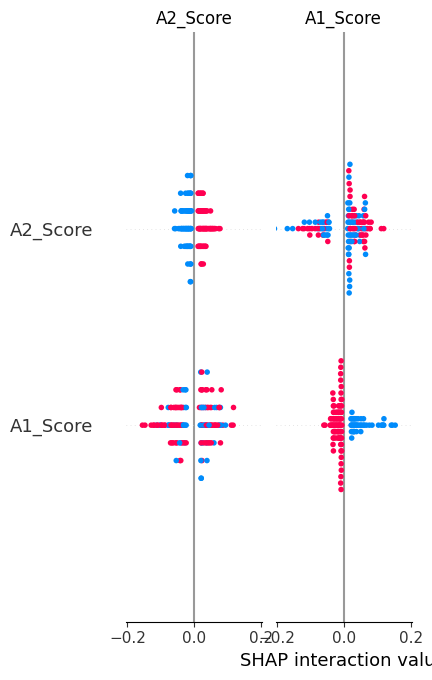

Force plot display skipped due to SHAP version compatibility.


In [61]:
# -----------------------------
# 12. SHAP EXPLAINABILITY
# -----------------------------
# Use Random Forest for SHAP explanation
# Works best on numeric processed features

print("\nRunning SHAP on Random Forest...")

X_sample = X_test.copy()
X_sample = X_sample.apply(pd.to_numeric, errors="coerce").fillna(0)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)

# For many SHAP versions, binary classification uses index 1 for positive class
try:
    shap.summary_plot(shap_values[1], X_sample)
except:
    shap.summary_plot(shap_values, X_sample)

# Optional force plot for one instance
shap.initjs()

try:
    force_plot = shap.force_plot(
        explainer.expected_value[1],
        shap_values[1][0],
        X_sample.iloc[0]
    )
    display(force_plot)
except:
    print("Force plot display skipped due to SHAP version compatibility.")


In [62]:
# -----------------------------
# 13. FINAL BEST MODEL
# -----------------------------
best_model_row = comparison_df.sort_values(by="Accuracy", ascending=False).iloc[0]
print("\nBest Model Based on Accuracy:")
print(best_model_row)


Best Model Based on Accuracy:
Model        Random Forest
Accuracy          0.964539
Precision         0.971429
Recall            0.894737
F1-Score          0.931507
ROC-AUC           0.994124
Name: 1, dtype: object


In [64]:
# Find best model based on accuracy
best_model = comparison_df.sort_values(by="Accuracy", ascending=False).iloc[0]

print("===================================")
print("        BEST MODEL RESULT")
print("===================================")

print(f"Model Name   : {best_model['Model']}")
print(f"Accuracy     : {best_model['Accuracy']:.4f}")
print(f"Precision    : {best_model['Precision']:.4f}")
print(f"Recall       : {best_model['Recall']:.4f}")
print(f"F1-Score     : {best_model['F1-Score']:.4f}")
print(f"ROC-AUC Score: {best_model['ROC-AUC']:.4f}")

        BEST MODEL RESULT
Model Name   : Random Forest
Accuracy     : 0.9645
Precision    : 0.9714
Recall       : 0.8947
F1-Score     : 0.9315
ROC-AUC Score: 0.9941


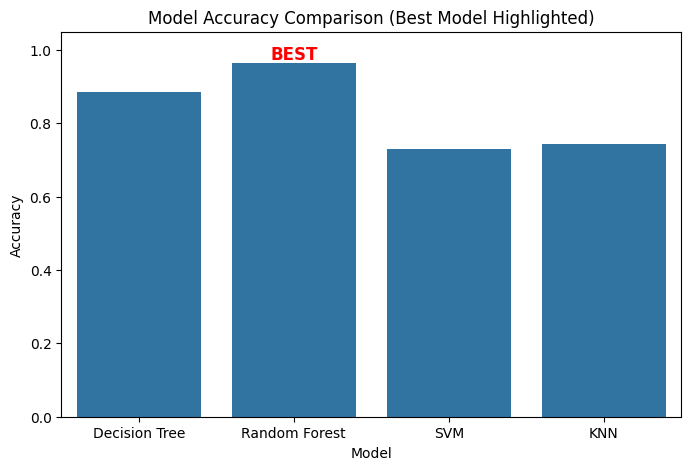

In [65]:
plt.figure(figsize=(8,5))

sns.barplot(x="Model", y="Accuracy", data=comparison_df)

# highlight best model
best_model_name = best_model["Model"]

for i, model in enumerate(comparison_df["Model"]):
    if model == best_model_name:
        plt.text(i, best_model["Accuracy"] + 0.01, "BEST", 
                 ha='center', color='red', fontsize=12, fontweight='bold')

plt.title("Model Accuracy Comparison (Best Model Highlighted)")
plt.ylim(0, 1.05)
plt.show()

In [63]:
# -----------------------------
# 14. CONCLUSION
# -----------------------------
print("\nConclusion:")
print("This notebook preprocesses the ASD dataset, trains multiple machine learning models,")
print("compares them using Accuracy, Precision, Recall, F1-Score, and ROC-AUC,")
print("visualizes confusion matrices and ROC curves, and explains the Random Forest model using SHAP.")


Conclusion:
This notebook preprocesses the ASD dataset, trains multiple machine learning models,
compares them using Accuracy, Precision, Recall, F1-Score, and ROC-AUC,
visualizes confusion matrices and ROC curves, and explains the Random Forest model using SHAP.
